In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import random

from data_analysis_fcns.DIL_Logger import DIL_Logger
from data_analysis_fcns.DIL_Metrics import plot_results

print("cuda" if torch.cuda.is_available() else "cpu")

cuda


In [2]:
# ----------------------------------------
# Reproducibility
# ----------------------------------------
torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------------------
# Dataset: CIFAR-10
# ----------------------------------------
transform = transforms.Compose([
    transforms.Resize(224),  # ConvNeXt expects 224x224
    transforms.ToTensor(),
])

full_dataset = torchvision.datasets.CIFAR10(
    root="./datasets",
    train=True,
    download=False,
    transform=transform
)

num_classes = 10
num_domains = 5

# 80/20 split
indices = np.arange(len(full_dataset))
np.random.shuffle(indices)

indices = indices[:200]

split = int(0.8 * len(indices))
train_indices = indices[:split]
test_indices = indices[split:]

train_dataset_full = Subset(full_dataset, train_indices)
test_dataset_full = Subset(full_dataset, test_indices)

# ----------------------------------------
# Create 5 partitions (domains)
# Split by index chunks (not class-based)
# ----------------------------------------
def partition_dataset(dataset, num_parts):
    length = len(dataset)
    part_size = length // num_parts
    subsets = []

    for i in range(num_parts):
        start = i * part_size
        end = (i + 1) * part_size if i < num_parts - 1 else length
        subsets.append(Subset(dataset, range(start, end)))

    return subsets

train_domains = partition_dataset(train_dataset_full, num_domains)
test_domains = partition_dataset(test_dataset_full, num_domains)



In [3]:

# ----------------------------------------
# Model: ConvNeXt Tiny
# ----------------------------------------
model = torchvision.models.convnext_tiny(weights=None)
model.classifier[2] = nn.Linear(model.classifier[2].in_features, 10)
model = model.to(device)

# ----------------------------------------
# Optimizer, Scheduler, Loss
# ----------------------------------------
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Cosine annealing per domain
epochs_per_domain = 5

# ----------------------------------------
# Continual Logger
# ----------------------------------------
logger = DIL_Logger(
    N=num_domains,
    C=num_classes,
    baseline=None,  # optionally pass baseline array
    save_dir="logs"
)


===== Training Domain 0 =====
Epoch 0 | Overall: 7.50 | AvgInc: 12.50 | Forgetting: 0.00
Epoch 1 | Overall: 7.50 | AvgInc: 0.00 | Forgetting: 0.00
Epoch 2 | Overall: 7.50 | AvgInc: 0.00 | Forgetting: 0.00
Epoch 3 | Overall: 7.50 | AvgInc: 0.00 | Forgetting: 0.00
Epoch 4 | Overall: 7.50 | AvgInc: 0.00 | Forgetting: 0.00

===== Training Domain 1 =====
Epoch 0 | Overall: 7.50 | AvgInc: 0.00 | Forgetting: 0.00
Epoch 1 | Overall: 7.50 | AvgInc: 0.00 | Forgetting: 0.00
Epoch 2 | Overall: 7.50 | AvgInc: 0.00 | Forgetting: 0.00
Epoch 3 | Overall: 7.50 | AvgInc: 0.00 | Forgetting: 0.00
Epoch 4 | Overall: 7.50 | AvgInc: 0.00 | Forgetting: 0.00

===== Training Domain 2 =====
Epoch 0 | Overall: 7.50 | AvgInc: 8.33 | Forgetting: 0.00
Epoch 1 | Overall: 7.50 | AvgInc: 8.33 | Forgetting: 0.00
Epoch 2 | Overall: 7.50 | AvgInc: 8.33 | Forgetting: 0.00
Epoch 3 | Overall: 7.50 | AvgInc: 8.33 | Forgetting: 0.00
Epoch 4 | Overall: 7.50 | AvgInc: 8.33 | Forgetting: 0.00

===== Training Domain 3 =====
Epoch

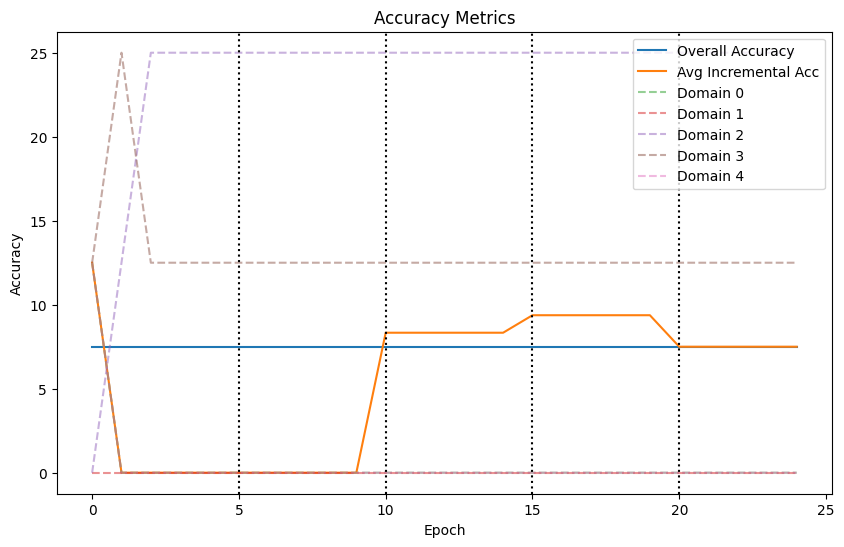

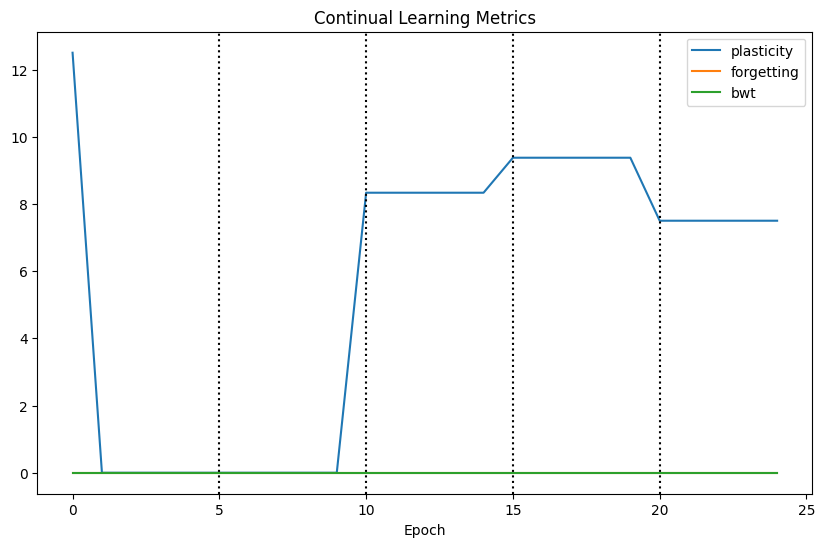

In [4]:

# ----------------------------------------
# Training Loop
# ----------------------------------------
for domain_id in range(num_domains):

    print(f"\n===== Training Domain {domain_id} =====")

    train_loader = DataLoader(
        train_domains[domain_id],
        batch_size=128,
        shuffle=True,
        num_workers=4
    )

    test_loaders = [
        DataLoader(d, batch_size=256, shuffle=False, num_workers=4)
        for d in test_domains
    ]

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs_per_domain
    )

    for epoch in range(epochs_per_domain):

        # -----------------------------
        # Train
        # -----------------------------
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

        scheduler.step()

        # -----------------------------
        # Evaluate
        # -----------------------------
        domain_acc, overall_acc, preds, targets = \
            logger.evaluate(model, test_loaders, device)

        metrics = logger.compute_metrics(
            domain_id,
            epoch,
            domain_acc
        )

        metrics["overall_acc"] = float(overall_acc)

        logger.log(metrics)

        print(
            f"Epoch {epoch} | "
            f"Overall: {overall_acc:.2f} | "
            f"AvgInc: {metrics['avg_inc_acc']:.2f} | "
            f"Forgetting: {metrics['forgetting']:.2f}"
        )

    # -----------------------------
    # Finalize domain
    # -----------------------------
    logger.finalize_domain(domain_acc, preds, targets)

# ----------------------------------------
# Save and Plot
# ----------------------------------------
logger.save()
plot_results("logs")